# P3 - Using cartopy for mapping
## MCLJES008 - Jessica Mc Lean - 2025/03/17

### For this plot of The Antarctic continent and the Southern Ocean starting from 60°S, I chose to make use of the Orthographic projection to portray the scale and dimensions of the Antarctic continent and the south ocean. The projection also shows a wider extent which I think adds in the visualisation of the Southern Ocean and further I think the round globe like shape that the projection produces is very realistic to what is seen from satelittes for example. I also preferred this projection aesthetically over those projections like from Plate Carree. Further I think the distortion in the orthographic projection for the Antarctic continent is less extensive than other projections. 

In [8]:
### Firstly, the necessary libraries need to be imported 

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

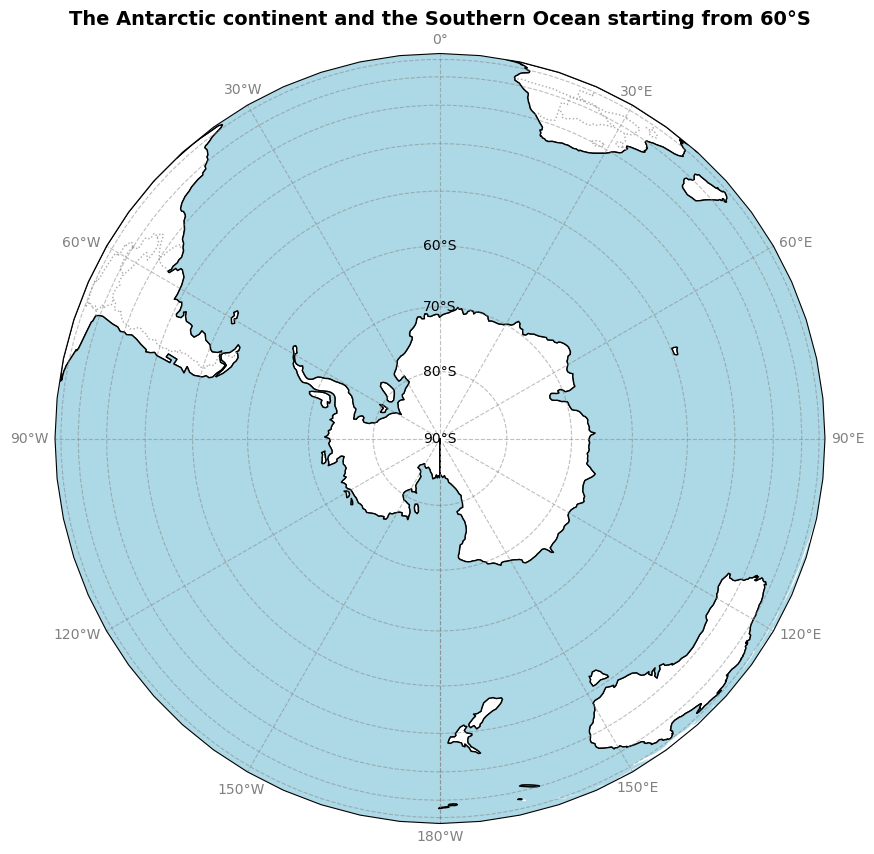

In [12]:
def setup_map(projection, title):
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': projection})
    ax.coastlines(resolution='110m', color='black') 


    gl = ax.gridlines(draw_labels=True, linestyle='--', color='gray', alpha=0.5)
    gl.xlocator = plt.MultipleLocator(30)  
    gl.ylocator = plt.MultipleLocator(10)  
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {'size': 10, 'color': 'gray'}
    gl.ylabel_style = {'size': 10, 'color': 'gray'}
    gl.xlabels_top = False  
    gl.ylabels_right = False  


    latitudes = [-60, -70, -80, -90]  
    longitude = 0 
    for lat in latitudes:
        ax.text(
            longitude, lat, f"{abs(lat)}°S", transform=ccrs.Geodetic(),
            fontsize=10, color='black', ha='center', va='center'
        )

 
    ax.add_feature(cfeature.LAND, facecolor='white', edgecolor='black')  # Land in white
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue')  # Ocean in light blue
    ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='darkgray')  # Country borders
    ax.set_title(title, fontsize=14, weight='bold')
    return ax

# Set up the projection and title
projection = ccrs.Orthographic(central_longitude=0, central_latitude=-90)  # South Pole view
ax = setup_map(projection, 'The Antarctic continent and the Southern Ocean starting from 60°S')

# Show the plot
plt.show()


### Next, The South Atlantic, from 20°S to 50°S. The map should show the following locations: Walvis Bay, Cape Town, Rio de Janeiro, Montevideo will be plotted 
### Originally, the map projection I chose was Robinson as it is suggested that this projection has reduced distortion away from the poles. However, I find the curve that the orthographic projection provides is more aesthetically appealling and true to the curvature of the earth. However, I think that this also creates more distortion as this projection - orthographic - appears to have more distortion away from the poles. I also chose this projection as the extent is much better than the Robinson projection. Specifically, the points that are plotted Walvis, Cape Town, Rio and Montevideo are more visbily seen like they are shown better in this projection than others. 

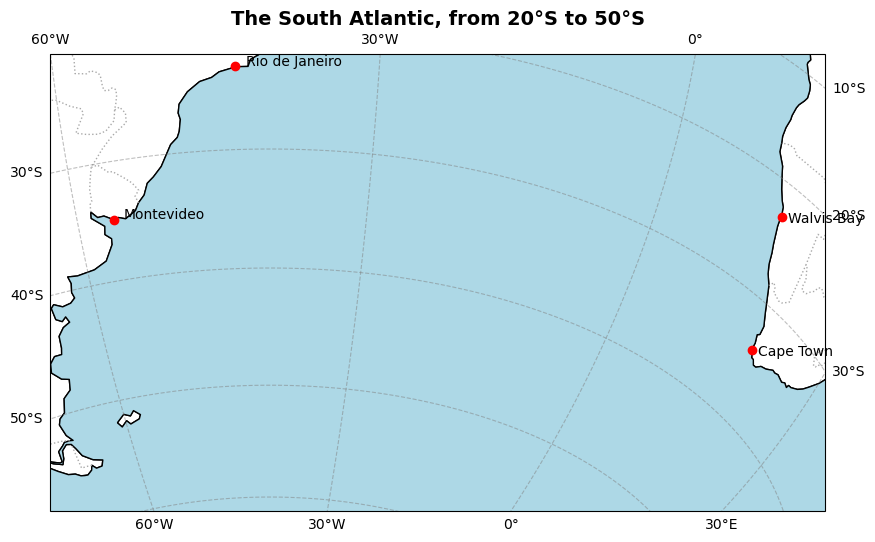

In [43]:
def setup_map(projection, title, extent=None):
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': projection})
    ax.coastlines(resolution='110m', color='black')


    if extent:
        ax.set_extent(extent, crs=ccrs.PlateCarree())

    # Add gridlines
    gl = ax.gridlines(draw_labels=True, linestyle='--', color='gray', alpha=0.5)
    gl.xlocator = plt.MultipleLocator(30) 
    gl.ylocator = plt.MultipleLocator(10) 

    # Add map features
    ax.add_feature(cfeature.LAND, facecolor='white', edgecolor='black') 
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue') 
    ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='darkgray') 
    ax.set_title(title, fontsize=14, weight='bold')
    return ax

# Set up the projection and title for the South Atlantic region
projection = ccrs.Orthographic(central_longitude=-40, central_latitude=-35)  
extent = [-60, 20, -50, -20] 
ax = setup_map(projection, 'The South Atlantic, from 20°S to 50°S', extent)
locations = {
    'Walvis Bay': (14.5053, -22.9576), 
    'Cape Town': (18.4241, -33.9249), 
    'Rio de Janeiro': (-43.1729, -22.9068), 
    'Montevideo': (-56.1645, -34.9011)
}
for city, coord in locations.items():
    ax.plot(*coord, marker='o', color='red', transform=ccrs.PlateCarree())
    ax.text(coord[0] + 1, coord[1], city, transform=ccrs.PlateCarree())
plt.show()


### Lastly, a series of 3 panels showing the use of different coastline resolutions from the GSHHG database in a map of False Bay will be plotted with the the coarse, intermediate and full resolutions shown 
### The projection chosen for this plot was the Robinson Projection. I used this one as it seemed the least distorted and I could make use of the extent function through use of this projection whereas with Lambert Conformal Conic projections this is not the case. Further, this projection supplies sufficient detail in terms of mapping the complexities of the landmasses. 

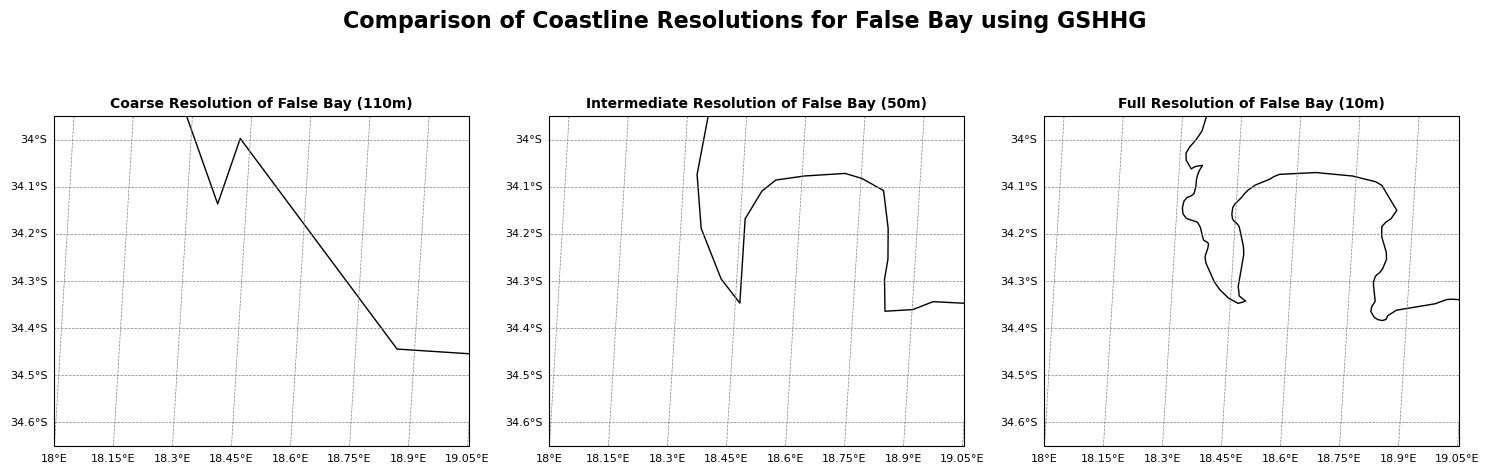

In [38]:
def plot_false_bay(ax, resolution, title):
    # Adjust the extent for False Bay with the specified latitude range
    ax.set_extent([18, 19, -34.65, -33.95], crs=ccrs.PlateCarree())  
    ax.coastlines(resolution=resolution, color='black', linewidth=1)
    ax.add_feature(cfeature.LAND, facecolor='white')
    ax.add_feature(cfeature.OCEAN, facecolor='white')
    
    # Add gridlines
    gl = ax.gridlines(draw_labels=True, color='gray', linestyle='--', linewidth=0.5)
    gl.top_labels = False  
    gl.right_labels = False  
    gl.xlabel_style = {'size': 8, 'color': 'black'}
    gl.ylabel_style = {'size': 8, 'color': 'black'}
    
    ax.set_title(title, fontsize=10, weight='bold')

fig, axes = plt.subplots(1, 3, figsize=(15, 5), subplot_kw={'projection': ccrs.Robinson()})

plot_false_bay(axes[0], resolution='110m', title='Coarse Resolution of False Bay (110m)')
plot_false_bay(axes[1], resolution='50m', title='Intermediate Resolution of False Bay (50m)')
plot_false_bay(axes[2], resolution='10m', title='Full Resolution of False Bay (10m)')

fig.suptitle('Comparison of Coastline Resolutions for False Bay using GSHHG', fontsize=16, weight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.95])

# Show the final plot
plt.show()